# Laboratorium 7 - Przeplyw Optyczny


## Zadanie 1 - Block Matching

Od tego miejsca zaczyna sie implementacja podstawowej metody block matching: wczytanie klatek, estymacja przeplywu i wizualizacja HSV.


In [13]:
from __future__ import annotations

from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


def find_sequence_frames(sequence_dir: Path, suffixes: tuple[str, ...] = (".png", ".jpg", ".jpeg", ".bmp")) -> list[Path]:
    frames = [p for p in sorted(sequence_dir.iterdir()) if p.suffix.lower() in suffixes]
    if len(frames) < 2:
        msg = f"Need at least two image frames in: {sequence_dir}"
        raise ValueError(msg)
    return frames


def load_frame_pair(
    *,
    frames: list[Path],
    index_prev: int,
    index_next: int,
    downsample_factor: int = 1,
) -> tuple[np.ndarray, np.ndarray]:
    bgr_prev = cv2.imread(str(frames[index_prev]), cv2.IMREAD_COLOR)
    bgr_next = cv2.imread(str(frames[index_next]), cv2.IMREAD_COLOR)
    if bgr_prev is None or bgr_next is None:
        msg = "Failed to read one of the selected frames."
        raise ValueError(msg)

    gray_prev = cv2.cvtColor(bgr_prev, cv2.COLOR_BGR2GRAY)
    gray_next = cv2.cvtColor(bgr_next, cv2.COLOR_BGR2GRAY)

    if downsample_factor > 1:
        scale = 1.0 / float(downsample_factor)
        gray_prev = cv2.resize(gray_prev, (0, 0), fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
        gray_next = cv2.resize(gray_next, (0, 0), fx=scale, fy=scale, interpolation=cv2.INTER_AREA)

    return gray_prev, gray_next


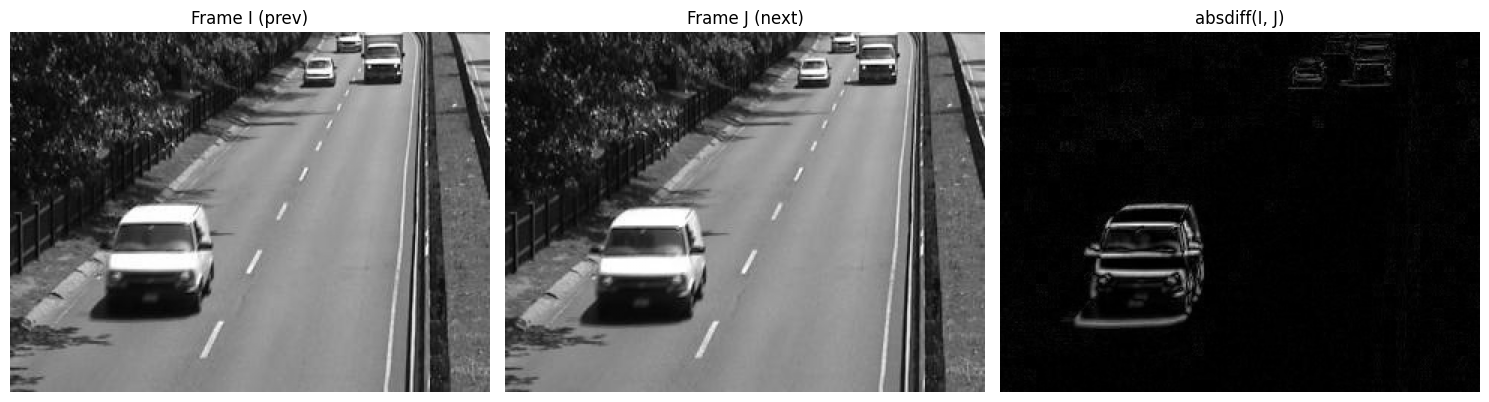

In [14]:
sequence_dir = Path("./data/highway/input")
frame_prev_index = 150
frame_next_index = 151
downsample_factor = 1

frames = find_sequence_frames(sequence_dir=sequence_dir)
I, J = load_frame_pair(
    frames=frames,
    index_prev=frame_prev_index,
    index_next=frame_next_index,
    downsample_factor=downsample_factor,
)

diff_abs = cv2.absdiff(I, J)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(I, cmap="gray")
axes[0].set_title("Frame I (prev)")
axes[1].imshow(J, cmap="gray")
axes[1].set_title("Frame J (next)")
axes[2].imshow(diff_abs, cmap="gray")
axes[2].set_title("absdiff(I, J)")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()


In [15]:
def build_motion_mask(
    *,
    I_gray: np.ndarray,
    J_gray: np.ndarray,
    threshold: int,
    kernel_size: int,
    iterations: int,
) -> np.ndarray:
    diff = cv2.absdiff(I_gray, J_gray)
    _, binary = cv2.threshold(diff, threshold, 255, cv2.THRESH_BINARY)
    kernel = np.ones((kernel_size, kernel_size), dtype=np.uint8)
    dilated = cv2.dilate(binary, kernel, iterations=iterations)
    return dilated


def block_matching_flow(
    *,
    I_gray: np.ndarray,
    J_gray: np.ndarray,
    window_size: int = 7,
    search_x: int = 3,
    search_y: int = 3,
    use_motion_mask: bool = True,
    diff_threshold: int = 20,
    dilate_kernel_size: int = 5,
    dilate_iterations: int = 1,
) -> tuple[np.ndarray, np.ndarray, np.ndarray | None]:
    if window_size % 2 == 0:
        msg = "window_size must be odd (e.g. 7, 9, 11)."
        raise ValueError(msg)

    half_window = window_size // 2
    height, width = I_gray.shape

    u = np.zeros((height, width), dtype=np.float32)
    v = np.zeros((height, width), dtype=np.float32)

    motion_mask: np.ndarray | None = None
    if use_motion_mask:
        motion_mask = build_motion_mask(
            I_gray=I_gray,
            J_gray=J_gray,
            threshold=diff_threshold,
            kernel_size=dilate_kernel_size,
            iterations=dilate_iterations,
        )

    for j in range(half_window, height - half_window):
        for i in range(half_window, width - half_window):
            if motion_mask is not None and motion_mask[j, i] == 0:
                continue

            ref_patch = np.float32(
                I_gray[
                    j - half_window : j + half_window + 1,
                    i - half_window : i + half_window + 1,
                ]
            )

            best_dist = np.inf
            best_di = 0
            best_dj = 0

            for dj in range(-search_y, search_y + 1):
                for di in range(-search_x, search_x + 1):
                    cj = j + dj
                    ci = i + di

                    if (
                        cj - half_window < 0
                        or cj + half_window >= height
                        or ci - half_window < 0
                        or ci + half_window >= width
                    ):
                        continue

                    cand_patch = np.float32(
                        J_gray[
                            cj - half_window : cj + half_window + 1,
                            ci - half_window : ci + half_window + 1,
                        ]
                    )
                    dist = np.sqrt(np.sum(np.square(cand_patch - ref_patch)))

                    if dist < best_dist:
                        best_dist = dist
                        best_di = di
                        best_dj = dj

            u[j, i] = float(best_di)
            v[j, i] = float(best_dj)

    return u, v, motion_mask


In [16]:
def flow_to_bgr_hsv(*, u: np.ndarray, v: np.ndarray) -> np.ndarray:
    mag, angle = cv2.cartToPolar(u, v)
    hsv = np.zeros((u.shape[0], u.shape[1], 3), dtype=np.uint8)
    hsv[..., 0] = np.uint8((angle * 90.0 / np.pi) % 180.0)
    hsv[..., 1] = np.uint8(cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX))
    hsv[..., 2] = 255

    # Swap S and V so zero-motion areas become black.
    hsv[..., [1, 2]] = hsv[..., [2, 1]]
    bgr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
    return bgr


def show_flow_results(
    *,
    I_gray: np.ndarray,
    J_gray: np.ndarray,
    u: np.ndarray,
    v: np.ndarray,
    motion_mask: np.ndarray | None,
) -> None:
    flow_bgr = flow_to_bgr_hsv(u=u, v=v)
    flow_rgb = cv2.cvtColor(flow_bgr, cv2.COLOR_BGR2RGB)
    diff = cv2.absdiff(I_gray, J_gray)

    ncols = 4 if motion_mask is not None else 3
    fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 5))

    axes[0].imshow(I_gray, cmap="gray")
    axes[0].set_title("Frame I")
    axes[1].imshow(J_gray, cmap="gray")
    axes[1].set_title("Frame J")
    axes[2].imshow(flow_rgb)
    axes[2].set_title("Optical Flow (HSV)")

    if motion_mask is not None:
        axes[3].imshow(diff, cmap="gray")
        axes[3].imshow(motion_mask, cmap="jet", alpha=0.35)
        axes[3].set_title("absdiff + motion mask")

    for axis in axes:
        axis.axis("off")

    plt.tight_layout()
    plt.show()


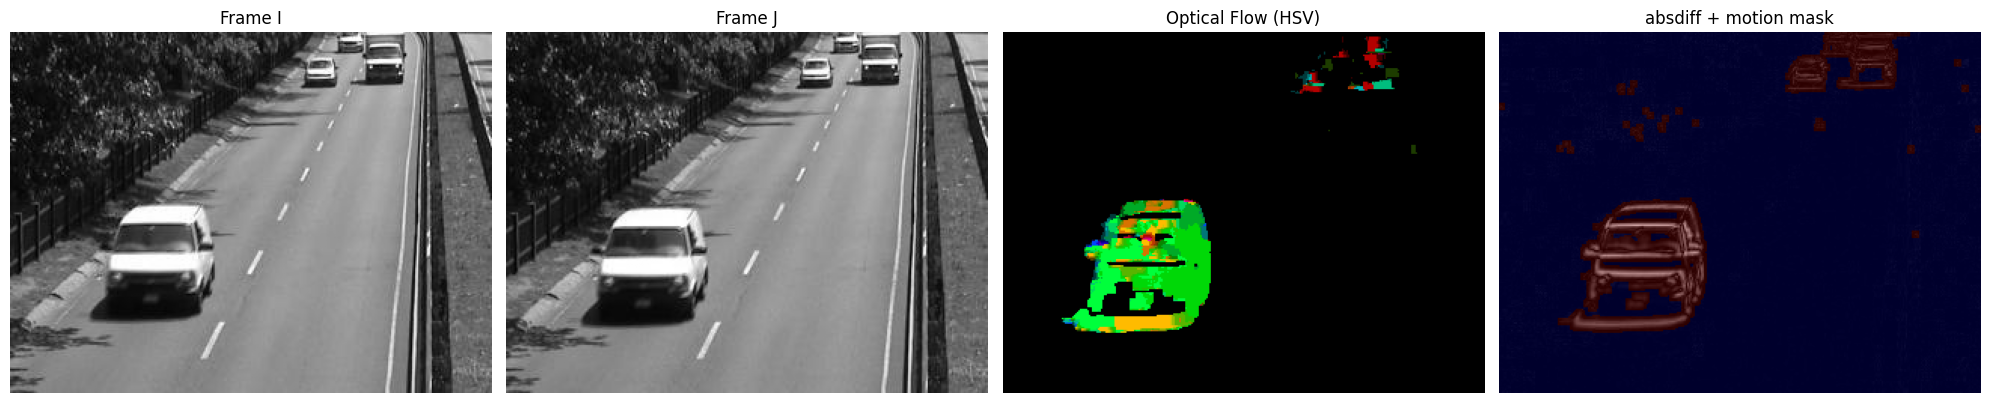

Flow range: u=[-3.0, 3.0], v=[-3.0, 3.0] | window=7, search=(3, 3)


In [17]:
u, v, motion_mask = block_matching_flow(
    I_gray=I,
    J_gray=J,
    window_size=7,
    search_x=3,
    search_y=3,
    use_motion_mask=True,
    diff_threshold=20,
    dilate_kernel_size=5,
    dilate_iterations=1,
)

show_flow_results(
    I_gray=I,
    J_gray=J,
    u=u,
    v=v,
    motion_mask=motion_mask,
)

print(
    f"Flow range: u=[{u.min():.1f}, {u.max():.1f}], v=[{v.min():.1f}, {v.max():.1f}] | "
    "window=7, search=(3, 3)"
)


## Zadanie 2 - Wersja wieloskalowa (piramidalna)

Od tego miejsca zaczyna sie implementacja metody coarse-to-fine: piramida obrazow, warping i akumulacja przeplywu.


In [18]:
from time import perf_counter


def of(
    *,
    J_org: np.ndarray,
    I_gray: np.ndarray,
    J_gray: np.ndarray,
    W2: int = 3,
    dY: int = 3,
    dX: int = 3,
    use_motion_mask: bool = True,
    diff_threshold: int = 20,
    dilate_kernel_size: int = 5,
    dilate_iterations: int = 1,
) -> tuple[np.ndarray, np.ndarray]:
    del J_org  # kept for compatibility with the task signature
    window_size = 2 * W2 + 1
    u, v, _ = block_matching_flow(
        I_gray=I_gray,
        J_gray=J_gray,
        window_size=window_size,
        search_x=dX,
        search_y=dY,
        use_motion_mask=use_motion_mask,
        diff_threshold=diff_threshold,
        dilate_kernel_size=dilate_kernel_size,
        dilate_iterations=dilate_iterations,
    )
    return u, v


def vis_flow(*, u: np.ndarray, v: np.ndarray, YX: tuple[int, int], name: str) -> None:
    del YX
    flow_bgr = flow_to_bgr_hsv(u=u, v=v)
    flow_rgb = cv2.cvtColor(flow_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(7, 5))
    plt.imshow(flow_rgb)
    plt.title(name)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


def pyramid(*, im: np.ndarray, max_scale: int) -> list[np.ndarray]:
    images = [im]
    for _ in range(1, max_scale):
        images.append(
            cv2.resize(images[-1], (0, 0), fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)
        )
    return images


def resize_flow_to_shape(
    *,
    u: np.ndarray,
    v: np.ndarray,
    target_shape: tuple[int, int],
) -> tuple[np.ndarray, np.ndarray]:
    target_h, target_w = target_shape
    src_h, src_w = u.shape
    scale_x = target_w / src_w
    scale_y = target_h / src_h

    u_resized = cv2.resize(u, (target_w, target_h), interpolation=cv2.INTER_LINEAR)
    v_resized = cv2.resize(v, (target_w, target_h), interpolation=cv2.INTER_LINEAR)

    u_scaled = np.float32(u_resized * scale_x)
    v_scaled = np.float32(v_resized * scale_y)
    return u_scaled, v_scaled


def warp_image_with_flow_integer(
    *,
    image: np.ndarray,
    u: np.ndarray,
    v: np.ndarray,
) -> np.ndarray:
    height, width = image.shape
    warped = np.copy(image)

    for j in range(height):
        for i in range(width):
            src_j = int(round(j + v[j, i]))
            src_i = int(round(i + u[j, i]))
            if 0 <= src_j < height and 0 <= src_i < width:
                warped[j, i] = image[src_j, src_i]

    return warped


In [19]:
def multiscale_block_matching_flow(
    *,
    I_gray: np.ndarray,
    J_gray: np.ndarray,
    max_scale: int = 3,
    W2: int = 3,
    dX: int = 3,
    dY: int = 3,
    use_motion_mask: bool = True,
    diff_threshold: int = 20,
    dilate_kernel_size: int = 5,
    dilate_iterations: int = 1,
    show_scale_debug: bool = False,
) -> tuple[np.ndarray, np.ndarray]:
    IP = pyramid(im=I_gray, max_scale=max_scale)
    JP = pyramid(im=J_gray, max_scale=max_scale)

    U = np.zeros(I_gray.shape, dtype=np.float32)
    V = np.zeros(I_gray.shape, dtype=np.float32)

    J_current = JP[-1]

    for s in range(max_scale - 1, -1, -1):
        I_level = IP[s]

        if J_current.shape != I_level.shape:
            J_current = cv2.resize(
                J_current,
                (I_level.shape[1], I_level.shape[0]),
                interpolation=cv2.INTER_LINEAR,
            )

        u_level, v_level = of(
            J_org=JP[s],
            I_gray=I_level,
            J_gray=J_current,
            W2=W2,
            dY=dY,
            dX=dX,
            use_motion_mask=use_motion_mask,
            diff_threshold=diff_threshold,
            dilate_kernel_size=dilate_kernel_size,
            dilate_iterations=dilate_iterations,
        )

        u_full, v_full = resize_flow_to_shape(
            u=u_level,
            v=v_level,
            target_shape=I_gray.shape,
        )
        U += u_full
        V += v_full

        if show_scale_debug:
            vis_flow(
                u=u_level,
                v=v_level,
                YX=I_level.shape,
                name=f"Flow at scale {s}",
            )

        if s > 0:
            next_shape = IP[s - 1].shape
            u_next, v_next = resize_flow_to_shape(
                u=u_level,
                v=v_level,
                target_shape=next_shape,
            )

            J_next_original = JP[s - 1]
            J_current = warp_image_with_flow_integer(
                image=J_next_original,
                u=u_next,
                v=v_next,
            )

    return U, V


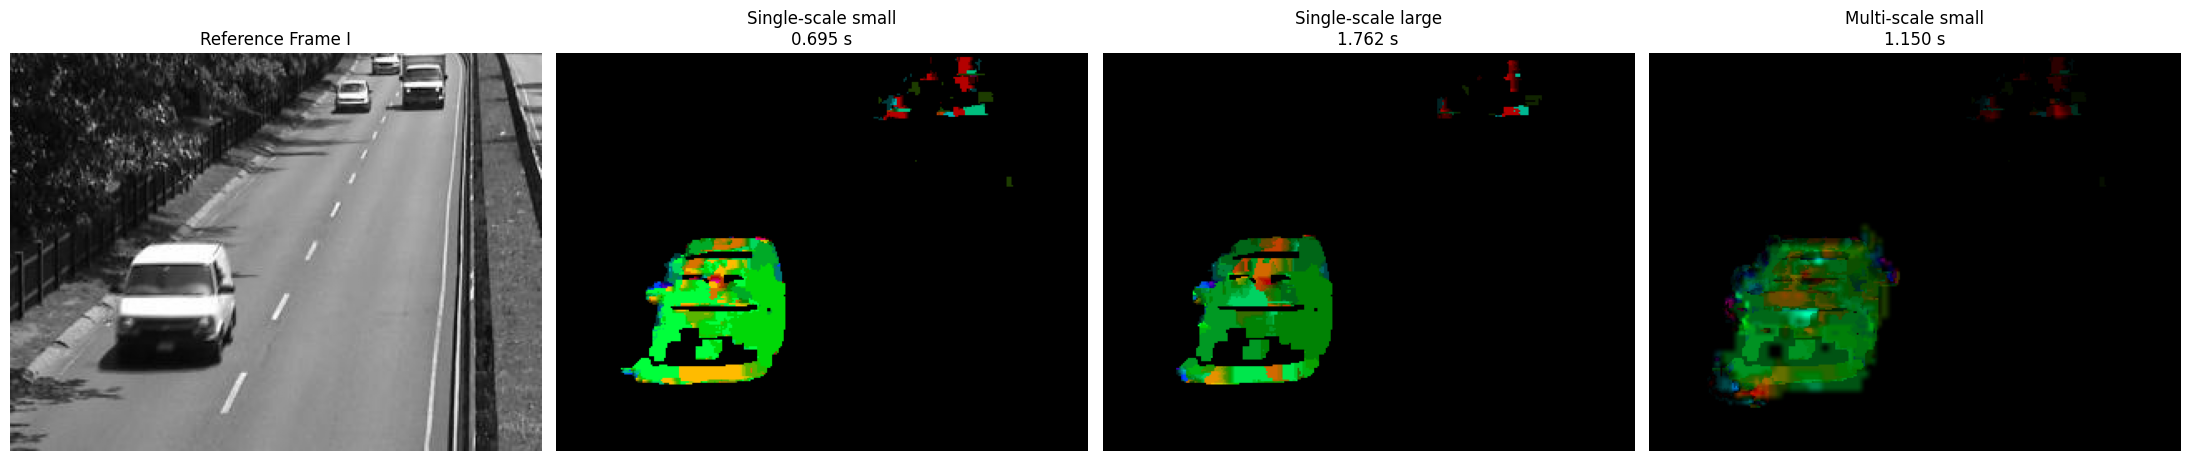

Runtime summary:
single-scale small: 0.695 s
single-scale large: 1.762 s
multi-scale small:  1.150 s


In [20]:
single_small_kwargs = dict(
    I_gray=I,
    J_gray=J,
    window_size=7,
    search_x=3,
    search_y=3,
    use_motion_mask=True,
    diff_threshold=20,
    dilate_kernel_size=5,
    dilate_iterations=1,
)

single_large_kwargs = dict(
    I_gray=I,
    J_gray=J,
    window_size=11,
    search_x=5,
    search_y=5,
    use_motion_mask=True,
    diff_threshold=20,
    dilate_kernel_size=5,
    dilate_iterations=1,
)

multi_kwargs = dict(
    I_gray=I,
    J_gray=J,
    max_scale=3,
    W2=3,
    dX=3,
    dY=3,
    use_motion_mask=True,
    diff_threshold=20,
    dilate_kernel_size=5,
    dilate_iterations=1,
    show_scale_debug=False,
)

start = perf_counter()
u_small, v_small, _ = block_matching_flow(**single_small_kwargs)
t_small = perf_counter() - start

start = perf_counter()
u_large, v_large, _ = block_matching_flow(**single_large_kwargs)
t_large = perf_counter() - start

start = perf_counter()
U_multi, V_multi = multiscale_block_matching_flow(**multi_kwargs)
t_multi = perf_counter() - start

flow_small_rgb = cv2.cvtColor(flow_to_bgr_hsv(u=u_small, v=v_small), cv2.COLOR_BGR2RGB)
flow_large_rgb = cv2.cvtColor(flow_to_bgr_hsv(u=u_large, v=v_large), cv2.COLOR_BGR2RGB)
flow_multi_rgb = cv2.cvtColor(flow_to_bgr_hsv(u=U_multi, v=V_multi), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
axes[0].imshow(I, cmap="gray")
axes[0].set_title("Reference Frame I")
axes[1].imshow(flow_small_rgb)
axes[1].set_title(f"Single-scale small\n{t_small:.3f} s")
axes[2].imshow(flow_large_rgb)
axes[2].set_title(f"Single-scale large\n{t_large:.3f} s")
axes[3].imshow(flow_multi_rgb)
axes[3].set_title(f"Multi-scale small\n{t_multi:.3f} s")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

print("Runtime summary:")
print(f"single-scale small: {t_small:.3f} s")
print(f"single-scale large: {t_large:.3f} s")
print(f"multi-scale small:  {t_multi:.3f} s")
